# 🔮 Chronos Demo: Rossmann Filiale 1097
### Zero-Shot Forecasting mit einem Foundation Model

*Gegenstück zur Prophet-Demo – **gleiche Daten**, damit wir direkt vergleichen können.*

Roter Faden: Prophet steckst du Wissen hinein (Feiertage, Promos). Chronos hat das Wissen **schon drin** und sagt **zero-shot** vorher – ohne `fit()`, ohne Feature-Engineering.

---
## 0 · Setup

Chronos braucht `chronos-forecasting` (+ das schon vorhandene PyTorch) und `scikit-learn` für die Metriken. Wir bewerten mit **denselben Metriken** wie bei Prophet (RMSE, MAE, MAPE).

In [1]:
# Einmalig installieren, falls noch nicht in der Env:
# !pip install chronos-forecasting scikit-learn

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import BaseChronosPipeline

np.random.seed(42)
torch.manual_seed(42)
print('Setup ok - torch', torch.__version__)

Setup ok - torch 2.5.1+cpu


In [2]:
# Metrik-Helfer (gleiche Logik wie in der Prophet-Demo, damit die Zahlen vergleichbar sind)
def print_metrics(y_true, y_pred, label='Modell'):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label:<32} RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:5.1f}%')
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

---
## 1 · Daten laden (Filiale 1097)

Exakt wie bei Prophet: nur **geöffnete Tage** mit Umsatz, Filiale 1097, chronologisch sortiert.

In [3]:
train = pd.read_csv('../data/rossmann-store-sales/train.csv',
                    parse_dates=['Date'], low_memory=False)

store = 1097
df = (train[(train['Store'] == store) & (train['Open'] == 1) & (train['Sales'] > 0)]
      .sort_values('Date')
      .reset_index(drop=True))

print(f'Filiale {store}: {len(df)} geöffnete Tage')
print('Zeitraum:', df['Date'].min().date(), 'bis', df['Date'].max().date())
df[['Date', 'Sales', 'Promo']].head()

Filiale 1097: 942 geöffnete Tage
Zeitraum: 2013-01-01 bis 2015-07-31


,Date,Sales,Promo
0,2013-01-01,5961,0
1,2013-01-02,6688,0
2,2013-01-03,7053,0
3,2013-01-04,6430,0
4,2013-01-05,5460,0


In [4]:
# Zeitreihe als reine Wertefolge. Chronos bekommt die Historie als Sequenz von Zahlen.
y = df['Sales'].to_numpy(dtype=float)

H = 42  # Prognosehorizont = letzte 42 geöffneten Tage (~6 Wochen) als Test
y_train, y_test = y[:-H], y[-H:]
dates_train, dates_test = df['Date'].iloc[:-H], df['Date'].iloc[-H:]

print(f'Train: {len(y_train)} Tage  |  Test: {len(y_test)} Tage')

Train: 900 Tage  |  Test: 42 Tage


---
## 2 · Zero-Shot Baseline (Chronos-Bolt small)

**Der Aha-Moment:** Kein `fit()`, keine Feiertage. Wir geben dem Modell nur die Historie (*inputs*) und fragen die nächsten Tage ab.

> Hinweis: Chronos sieht die Umsätze als reine Zahlenfolge (geöffnete Tage hintereinander). Anders als Prophet nutzt es die konkreten Datumswerte nicht – es erkennt Muster allein aus der Sequenz.

In [5]:
# Modell laden (beim 1. Mal Download von Hugging Face -> einmalig Internet nötig)
pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

# Zero-Shot-Vorhersage: nur Historie rein -> Quantile + Mittelwert raus
# Hinweis: das erste Argument heißt in der aktuellen Chronos-Version 'inputs'
quantiles, mean = pipe.predict_quantiles(
    inputs=torch.tensor(y_train, dtype=torch.float32),
    prediction_length=H,
    quantile_levels=[0.1, 0.5, 0.9],
)

# quantiles hat die Form [1, H, 3] -> [Serie, Zeitschritt, Quantil]
lo     = quantiles[0, :, 0].numpy()   # 10%-Quantil (unteres Band)
median = quantiles[0, :, 1].numpy()   # 50%-Quantil (Punktprognose)
hi     = quantiles[0, :, 2].numpy()   # 90%-Quantil (oberes Band)

m_baseline = print_metrics(y_test, median, 'Chronos Bolt-small (zero-shot)')

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Chronos Bolt-small (zero-shot)   RMSE=  1261.9  MAE=  1042.2  MAPE=  9.6%


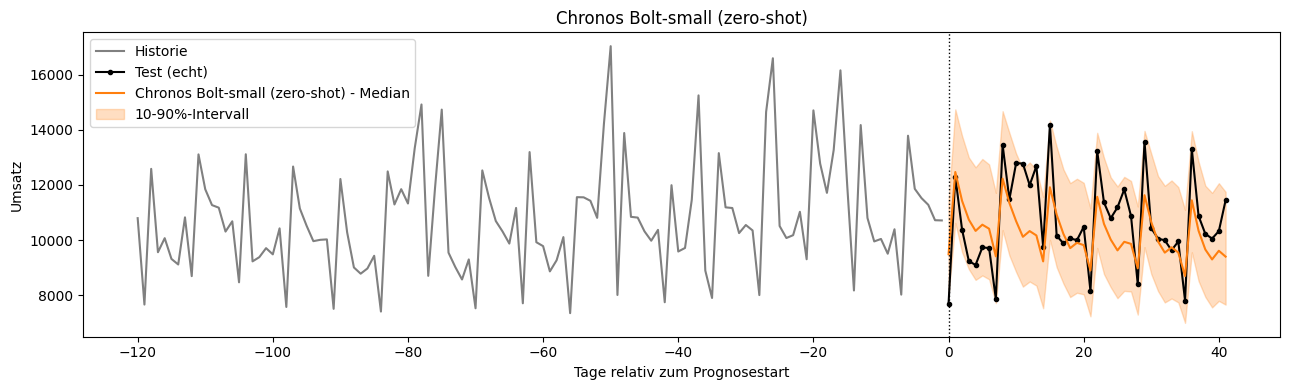

In [6]:
# Plot-Helfer: Ende der Historie + echte Testwerte + Forecast mit 10-90%-Band
def plot_forecast(y_train, y_true, median, lo, hi, label, n_context=120):
    H = len(y_true)
    x_hist = np.arange(-min(n_context, len(y_train)), 0)
    x_fc   = np.arange(0, H)
    plt.figure(figsize=(13, 4))
    plt.plot(x_hist, y_train[-len(x_hist):], color='gray', label='Historie')
    plt.plot(x_fc, y_true, color='black', marker='.', label='Test (echt)')
    plt.plot(x_fc, median, color='C1', label=f'{label} - Median')
    plt.fill_between(x_fc, lo, hi, color='C1', alpha=0.25, label='10-90%-Intervall')
    plt.axvline(0, color='k', ls=':', lw=1)
    plt.title(label)
    plt.xlabel('Tage relativ zum Prognosestart')
    plt.ylabel('Umsatz')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_forecast(y_train, y_test, median, lo, hi, 'Chronos Bolt-small (zero-shot)')

---
## 3 · Hebel 1: Kontextlänge

Bei Prophet haben wir **Feiertage** ergänzt. Bei Chronos ist der wichtigste Stellhebel, **wie viel Historie** das Modell sieht. Wir testen verschiedene Kontextlängen und vergleichen die Metriken.

In [7]:
results_ctx = []
for k in [60, 180, 365, len(y_train)]:
    ctx = y_train[-k:]                      # nur die letzten k Tage als Historie
    q, _ = pipe.predict_quantiles(
        inputs=torch.tensor(ctx, dtype=torch.float32),
        prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
    )
    med = q[0, :, 1].numpy()
    results_ctx.append(print_metrics(y_test, med, f'Kontext = {k} Tage'))

pd.DataFrame(results_ctx).set_index('label').round(1)

Kontext = 60 Tage                RMSE=  1553.9  MAE=  1397.8  MAPE= 13.8%
Kontext = 180 Tage               RMSE=  1261.9  MAE=  1102.1  MAPE= 10.6%
Kontext = 365 Tage               RMSE=  1160.5  MAE=   943.6  MAPE=  8.9%
Kontext = 900 Tage               RMSE=  1261.9  MAE=  1042.2  MAPE=  9.6%


,RMSE,MAE,MAPE
label,,,
Kontext = 60 Tage,1553.9,1397.8,13.8
Kontext = 180 Tage,1261.9,1102.1,10.6
Kontext = 365 Tage,1160.5,943.6,8.9
Kontext = 900 Tage,1261.9,1042.2,9.6


---
## 4 · Hebel 2: Modellgröße

Gegenstück zu Prophets „regionale Feiertage / Zeitfenster": mehr Modell-Power statt mehr Feature-Engineering. Wir vergleichen `bolt-tiny` → `bolt-small` → `bolt-base` (Genauigkeit vs. Rechenzeit).

In [8]:
results_size = []
for model_id in ['amazon/chronos-bolt-tiny', 'amazon/chronos-bolt-small', 'amazon/chronos-bolt-base']:
    p = BaseChronosPipeline.from_pretrained(model_id, device_map='cpu')
    t0 = time.time()
    q, _ = p.predict_quantiles(
        inputs=torch.tensor(y_train, dtype=torch.float32),
        prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
    )
    dt = time.time() - t0
    med = q[0, :, 1].numpy()
    r = print_metrics(y_test, med, model_id.split('/')[-1])
    r['Sekunden'] = round(dt, 2)
    results_size.append(r)

pd.DataFrame(results_size).set_index('label').round(1)

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

chronos-bolt-tiny                RMSE=  1650.2  MAE=  1321.8  MAPE= 12.4%


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/821M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

chronos-bolt-base                RMSE=  1029.7  MAE=   824.7  MAPE=  7.6%


,RMSE,MAE,MAPE,Sekunden
label,,,,
chronos-bolt-tiny,1650.2,1321.8,12.4,0.0
chronos-bolt-small,1261.9,1042.2,9.6,0.1
chronos-bolt-base,1029.7,824.7,7.6,0.4


---
## 5 · Hebel 3: Kovariate „Promo" (Chronos-2)

**Direktes Gegenstück zum Prophet-Regressor.** Chronos-2 kann zusätzliche Einflussgrößen (hier: `Promo`) als Kovariate nutzen – inkl. der *zukünftigen* (bekannten) Promo-Werte über `future_df`.

> Optional / Bonus. Braucht das Modell `amazon/chronos-2` und `pandas[pyarrow]`; lädt beim 1. Mal ~250 MB.

In [9]:
from chronos import Chronos2Pipeline

pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

# Vergangenheit: Datum, Ziel (Sales) und die Kovariate Promo
context_df = pd.DataFrame({
    'id': 'store_1097',
    'timestamp': dates_train.values,
    'target': y_train,
    'Promo': df['Promo'].to_numpy()[:-H],
})
# Zukunft: künftige Zeitpunkte + bekannte Promo-Werte, OHNE target
future_df = pd.DataFrame({
    'id': 'store_1097',
    'timestamp': dates_test.values,
    'Promo': df['Promo'].to_numpy()[-H:],
})

pred_df = pipe2.predict_df(
    context_df, future_df=future_df,
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
    id_column='id', timestamp_column='timestamp', target='target',
)

# Median-Spalte heißt '0.5', Punktprognose 'predictions'
med2 = pred_df['0.5'].to_numpy()
m_cov = print_metrics(y_test, med2, 'Chronos-2 + Promo (Kovariate)')

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 + Promo (Kovariate)    RMSE=   703.0  MAE=   532.1  MAPE=  4.8%


---
## 6 · Unsicherheit: Prognoseintervalle

Chronos ist **probabilistisch**: Es liefert Quantile, nicht nur einen Wert. Wir prüfen, wie gut das 10-90%-Band die echten Werte abdeckt (Soll: ~80%).

Abdeckung 10-90%-Band: 93% der Testwerte liegen im Band
Mittlere Bandbreite: 4158 Umsatz-Einheiten


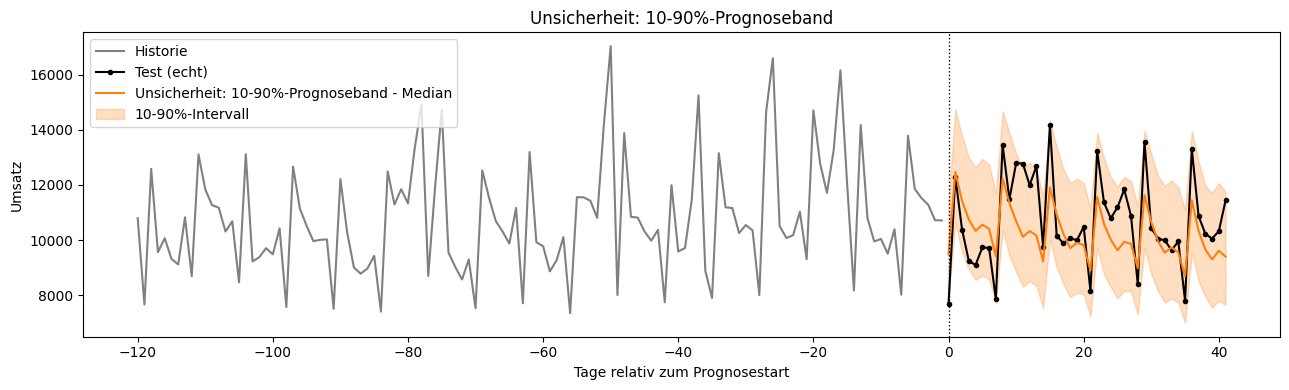

In [10]:
inside = (y_test >= lo) & (y_test <= hi)
print(f'Abdeckung 10-90%-Band: {inside.mean()*100:.0f}% der Testwerte liegen im Band')
print(f'Mittlere Bandbreite: {np.mean(hi - lo):.0f} Umsatz-Einheiten')
plot_forecast(y_train, y_test, median, lo, hi, 'Unsicherheit: 10-90%-Prognoseband')

---
## 6b · Chronos-Vorteil: Cold Start (wenig Historie)

Hier spielt Chronos seine Stärke aus: Wir tun so, als wäre 1097 eine **neue Filiale** mit nur 60 Tagen Historie. Prophet kann mit so wenig Daten die Jahressaison kaum lernen – Chronos bringt sein Vorwissen mit und sagt trotzdem sinnvoll vorher.

Als faire Messlatte *ohne* Vorwissen nehmen wir ein Seasonal-Naive-Modell (die letzte Woche wird wiederholt). Erwartung: Chronos schlägt es deutlich, obwohl beide gleich wenig Historie sehen.

> Tipp für die Präsentation: dieselben 60 Tage auch in Prophet füttern – Prophet wird die Saison kaum treffen. Das ist der überzeugendste „Chronos gewinnt"-Moment.

Chronos (nur 60 Tage Kontext)    RMSE=  1553.9  MAE=  1397.8  MAPE= 13.8%
Seasonal-Naive (letzte Woche)    RMSE=  1116.1  MAE=   942.0  MAPE=  9.0%


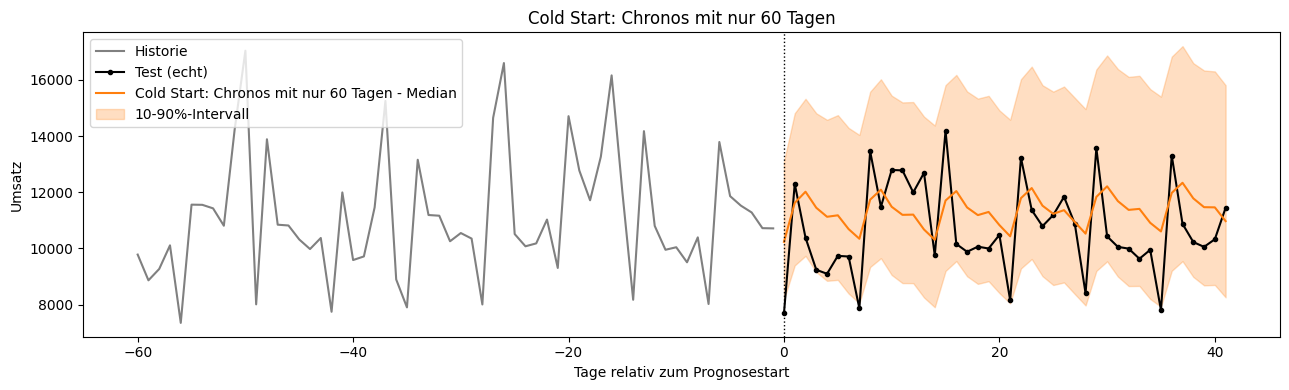

In [11]:
# 'Neue Filiale': nur die letzten 60 Tage als Historie verfügbar
short_ctx = 60
y_short = y_train[-short_ctx:]

# (a) Chronos zero-shot mit wenig Historie
q, _ = pipe.predict_quantiles(
    inputs=torch.tensor(y_short, dtype=torch.float32),
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
)
med_cold = q[0, :, 1].numpy(); lo_cold = q[0, :, 0].numpy(); hi_cold = q[0, :, 2].numpy()

# (b) Vergleich ohne Vorwissen: Seasonal-Naive (letzte Woche wiederholen)
season = 7
naive = np.array([y_short[-season + (i % season)] for i in range(H)])

print_metrics(y_test, med_cold, f'Chronos (nur {short_ctx} Tage Kontext)')
print_metrics(y_test, naive,    'Seasonal-Naive (letzte Woche)')
plot_forecast(y_short, y_test, med_cold, lo_cold, hi_cold, f'Cold Start: Chronos mit nur {short_ctx} Tagen')

---
## 7 · 🦢 Black-Swan-Stresstest (Flugdaten)

Gleicher Stresstest wie bei Prophet: Wie reagiert ein Foundation Model auf einen plötzlichen Strukturbruch (Corona-Einbruch im Flugverkehr)? Sieht Chronos den Crash kommen – oder extrapoliert es nur die gelernte Saisonalität?

> Wichtig fürs Fazit: Einen echten Black Swan kann **kein** Modell vorhersehen – Prophet so wenig wie Chronos. Dieser Test zeigt die Grenze *beider* Verfahren, nicht einen Chronos-Nachteil.

C:\Users\kaiws\anaconda3\envs\ts-tutorial\lib\site-packages\chronos\chronos_bolt.py:546: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


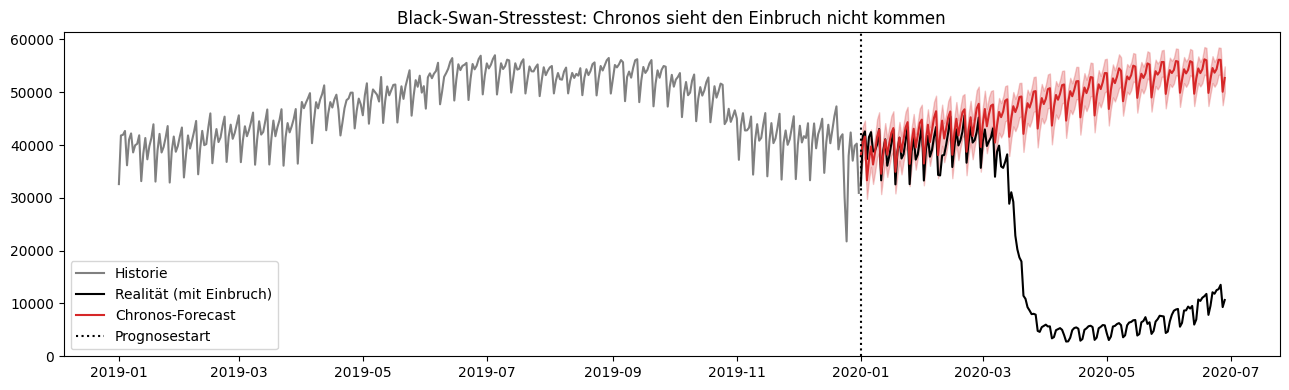

In [14]:
df_flights = pd.read_csv('../data/flights.csv', parse_dates=['FLT_DATE'])
daily = df_flights.groupby('FLT_DATE')['FLT_TOT_1'].sum().sort_index()
# Zeitzone entfernen, falls vorhanden (sonst Vergleich mit tz-naivem Timestamp -> Fehler)
if daily.index.tz is not None:
    daily.index = daily.index.tz_localize(None)
y_f = daily.to_numpy(dtype=float)

# Kontext: alles VOR dem Bruch (Anfang 2020). Forecast über den Bruch hinweg.
cut = daily.index.get_indexer([pd.Timestamp('2020-01-01')], method='nearest')[0]
Hf = 180  # ~6 Monate vorhersagen
ctx_f  = y_f[:cut]
true_f = y_f[cut:cut + Hf]

q, _ = pipe.predict_quantiles(
    inputs=torch.tensor(ctx_f, dtype=torch.float32),
    prediction_length=Hf, quantile_levels=[0.1, 0.5, 0.9],
)
med_f = q[0, :, 1].numpy(); lo_f = q[0, :, 0].numpy(); hi_f = q[0, :, 2].numpy()

start = max(0, cut - 365)
plt.figure(figsize=(13, 4))
plt.plot(daily.index[start:cut], y_f[start:cut], color='gray', label='Historie')
plt.plot(daily.index[cut:cut + Hf], true_f, color='black', label='Realität (mit Einbruch)')
plt.plot(daily.index[cut:cut + Hf], med_f, color='C3', label='Chronos-Forecast')
plt.fill_between(daily.index[cut:cut + Hf], lo_f, hi_f, color='C3', alpha=0.25)
plt.axvline(daily.index[cut], color='k', ls=':', label='Prognosestart')
plt.title('Black-Swan-Stresstest: Chronos sieht den Einbruch nicht kommen')
plt.legend(); plt.tight_layout(); plt.show()

---
## 8 · Fazit: Prophet vs. Chronos

Überblick über die Chronos-Varianten. Für den direkten Vergleich die RMSE/MAPE eures besten **Prophet**-Modells daneben eintragen.

- Aufwand: Feature-Engineering (Prophet) vs. Zero-Shot (Chronos)
- Erklärbarkeit (Prophet) vs. Bequemlichkeit (Chronos)
- Stärke von Chronos: wenig Historie / viele Reihen (siehe Cold Start, Abschnitt 6b)
- Wann würde man was nehmen?

In [13]:
summary = pd.DataFrame([m_baseline] + results_size).drop_duplicates('label').set_index('label')
print(summary.round(1))
print('\nTipp: RMSE/MAPE des besten Prophet-Modells hier daneben eintragen,')
print('um Prophet (Analyst-in-the-Loop) direkt mit Chronos (Zero-Shot) zu vergleichen.')

                                  RMSE     MAE  MAPE  Sekunden
label                                                         
Chronos Bolt-small (zero-shot)  1261.9  1042.2   9.6       NaN
chronos-bolt-tiny               1650.2  1321.8  12.4       0.0
chronos-bolt-small              1261.9  1042.2   9.6       0.1
chronos-bolt-base               1029.7   824.7   7.6       0.4

Tipp: RMSE/MAPE des besten Prophet-Modells hier daneben eintragen,
um Prophet (Analyst-in-the-Loop) direkt mit Chronos (Zero-Shot) zu vergleichen.
